# CHAPTER 6: PHÂN TÍCH VÀ DỰ BÁO CHUỖI THỜI GIAN

## Thực hiện phân tích chuỗi thời gian đối với tỷ lệ thất nghiệp hàng tháng của Mỹ được tải từ Nasdaq Data Link.

### 1. Nhập thư viện và xác thực:

In [24]:
import pandas as pd
import nasdaqdatalink
import seaborn as sns
from statsmodels.tsa.seasonal import seasonal_decompose

nasdaqdatalink.ApiConfig.api_key = "YOUR_API_KEY"

### 2. Tải số liệu từ năm 2010 đến năm 2019:

In [25]:
import pandas as pd

df = pd.read_csv("UNRATE.csv")
df["observation_date"] = pd.to_datetime(df["observation_date"])
df = df[
    (df["observation_date"] >= "2010-01-01") &
    (df["observation_date"] <= "2019-12-31")
]
df = df.rename(columns={
    "observation_date": "Date",
    "UNRATE": "unemp_rate"
})
df = df.set_index("Date")

df.head()

,unemp_rate
Date,
2010-01-01,9.8
2010-02-01,9.8
2010-03-01,9.9
2010-04-01,9.9
2010-05-01,9.6


### 3. Cộng giá trị trung bình trượt và độ lệch chuẩn:

<Axes: title={'center': 'Unemployment rate'}, xlabel='Date'>

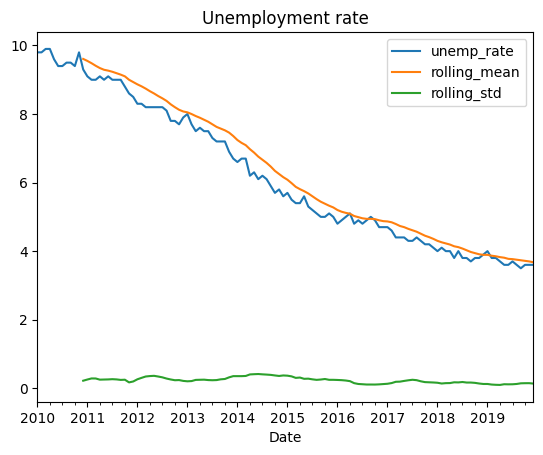

In [26]:
WINDOW_SIZE = 12 
df["rolling_mean"] = df["unemp_rate"].rolling(window=WINDOW_SIZE).mean()
df["rolling_std"] = df["unemp_rate"].rolling(window=WINDOW_SIZE).std()
df.plot(title="Unemployment rate")

### 4. Tiến hành phân tích thành phần theo mùa bằng mô hình cộng:

Text(0.5, 0.98, 'Additive Decomposition')

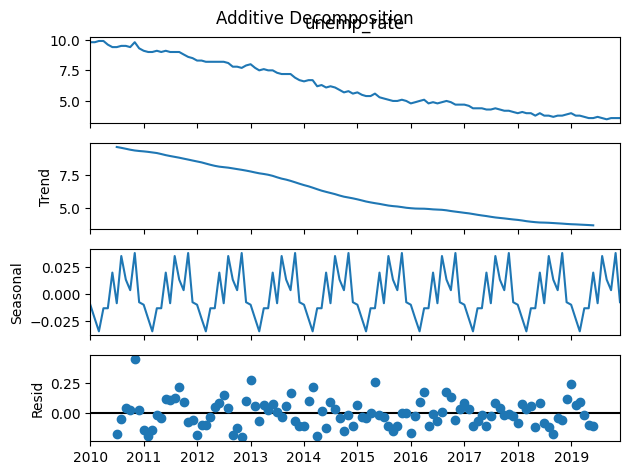

In [43]:
decomposition_result = seasonal_decompose(df['unemp_rate'], model='additive')

(
    decomposition_result
    .plot()
    .suptitle('Additive Decomposition')
)

### Phân tích bằng phương pháp `STL`

Text(0.5, 0.98, 'STL Decomposition')

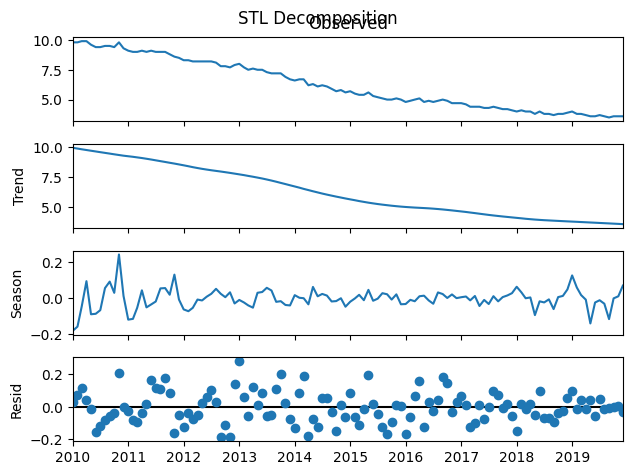

In [28]:
from statsmodels.tsa.seasonal import STL

stl_decomposition = STL(df[['unemp_rate']]).fit()
stl_decomposition.plot() \
                 .suptitle('STL Decomposition') 

## Kiểm tra chuỗi thời gian tỷ lệ thất nghiệp hàng tháng có ổn định hay không

### 1. Nhập thư viện:

In [29]:
import pandas as pd
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.stattools import adfuller,kpss

### 2. Định nghĩa một hàm để chạy bài kiểm tra ADF:

In [30]:
def adf_test(x):
    indices = ['Test Statistic', 'p-value', '# of Lags Used', 'Number of Observations Used']

    adf_test = adfuller(x, autolag='AIC')
    results = pd.Series(adf_test[0:4], index=indices)

    for key, value in adf_test[4].items():
        results[f'Critical Value ({key})'] = value

    return results

In [31]:
adf_test(df['unemp_rate'])

Test Statistic                  -2.193725
p-value                          0.208531
# of Lags Used                  11.000000
Number of Observations Used    108.000000
Critical Value (1%)             -3.492401
Critical Value (5%)             -2.888697
Critical Value (10%)            -2.581255
dtype: float64

### 3. Định nghĩa một hàm để chạy thử nghiệm KPSS:

In [44]:
def kpss_test(x, h0_type='c'):
    indices = ['Test Statistic', 'p-value', '# of Lags Used']

    kpss_result = kpss(x, regression=h0_type)
    results = pd.Series(kpss_result[0:3], index=indices)

    for key, value in kpss_result[3].items():
        results[f'Critical Value ({key})'] = value

    return results

In [46]:
kpss_test(df['unemp_rate'])

C:\Users\BAO TRAN\AppData\Local\Temp\ipykernel_23164\2697013262.py:4: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is smaller than the p-value returned.

  kpss_result = kpss(x, regression=h0_type)


Test Statistic           1.786633
p-value                  0.010000
# of Lags Used           6.000000
Critical Value (10%)     0.347000
Critical Value (5%)      0.463000
Critical Value (2.5%)    0.574000
Critical Value (1%)      0.739000
dtype: float64

### 4. Tạo biểu đồ ACF/PACF:

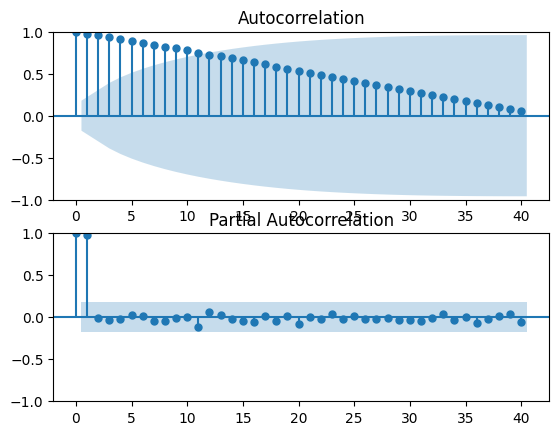

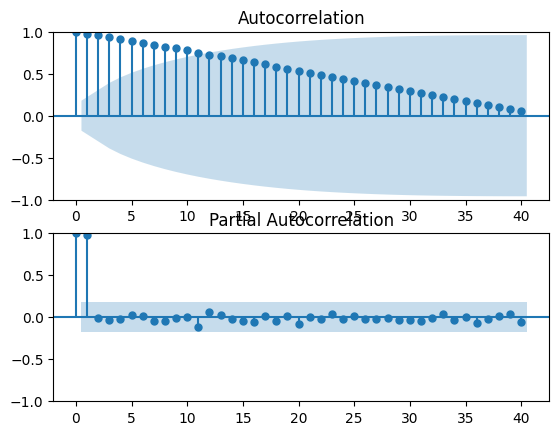

In [50]:
import matplotlib.pyplot as plt

N_LAGS = 40
SIGNIFICANCE_LEVEL = 0.05

fig, ax = plt.subplots(2, 1)
plot_acf(df['unemp_rate'], lags=N_LAGS, ax=ax[0],alpha=SIGNIFICANCE_LEVEL)
plot_pacf(df['unemp_rate'], lags=N_LAGS, ax=ax[1],alpha=SIGNIFICANCE_LEVEL)

### Kiểm tra ADF bằng thư viện `arch`:

In [52]:
from arch.unitroot import ADF
adf = ADF(df['unemp_rate'])
print(adf.summary().as_text())

   Augmented Dickey-Fuller Results   
Test Statistic                 -2.194
P-value                         0.209
Lags                               11
-------------------------------------

Trend: Constant
Critical Values: -3.49 (1%), -2.89 (5%), -2.58 (10%)
Null Hypothesis: The process contains a unit root.
Alternative Hypothesis: The process is weakly stationary.


### Bài kiểm tra Zivot-Andrews:

In [53]:
from arch.unitroot import ZivotAndrews
za = ZivotAndrews(df["unemp_rate"])
print(za.summary().as_text())

        Zivot-Andrews Results        
Test Statistic                 -2.773
P-value                         0.959
Lags                               11
-------------------------------------

Trend: Constant
Critical Values: -5.28 (1%), -4.81 (5%), -4.57 (10%)
Null Hypothesis: The process contains a unit root with a single structural break.
Alternative Hypothesis: The process is trend and break stationary.


## Chuyển đổi chuỗi từ không ổn định sang ổn định:

### 1. Nhập các thư viện, xác thực và cập nhật dữ liệu lạm phát:

In [54]:
import pandas as pd
import numpy as np
import nasdaqdatalink
import cpi 
from datetime import date
from chapter_6_utils import test_autocorrelation

nasdaqdatalink.ApiConfig.api_key = "YOUR_API_KEY"

C:\Users\BAO TRAN\AppData\Local\Temp\ipykernel_23164\607562887.py:4: StaleDataWarning: CPI data is out of date. To accurately inflate to today's dollars, you must run `cpi.update()`.
  import cpi


### 2. Tải xuống giá vàng và lấy mẫu lại theo giá trị hàng tháng:

In [55]:
df = (
    nasdaqdatalink.get("WGC/GOLD_MONAVG_USD", 
                       start_date="2000-01-01", 
                       end_date="2010-12-31")
    .rename(columns={"Value": "price"})
    .resample("M")
    .last()
)

DataLinkError: (Status 403) Something went wrong. Please try again. If you continue to have problems, please contact us at connect@data.nasdaq.com.

### 3. Điều chỉnh giá vàng về giá trị USD ngày 31/12/2010 và vẽ biểu đồ kết quả:

In [ ]:
DEFL_DATE = date(2010, 12, 31)

df["dt_index"] = pd.to_datetime(df.index)
df["price_deflated"] = df.apply(lambda x: cpi.inflate(x["price"], x["dt_index"], DEFL_DATE), axis=1)

(
    df.loc[:, ["price", "price_deflated"]]
    .plot(title="Gold price (Deflated)")
)

### 4. Áp dụng logarit tự nhiên cho chuỗi dữ liệu đã được điều chỉnh theo lạm phát và vẽ biểu đồ cùng với các chỉ số luân chuyển:

In [ ]:
WINDOW = 12
selected_columns = ["price_log", "rolling_mean_log", "rolling_std_log"]

df["price_log"] = np.log(df["price_deflated"])
df["rolling_mean_log"] = df["price_log"].rolling(window=WINDOW).mean()
df["rolling_std_log"] = df["price_log"].rolling(window=WINDOW).std()

(
    df[selected_columns]
    .plot(title="Gold price (Log-Deflated)",
          subplots=True)
)

### 5. Sử dụng hàm test_autocorrelation để kiểm tra xem chuỗi dữ liệu đã trở nên ổn định hay chưa:

In [ ]:
fig = test_autocorrelation(df["price_log"])

### 6. Áp dụng phép lấy sai phân cho chuỗi và vẽ biểu đồ kết quả:

In [ ]:
selected_columns = ["price_log_diff", "rolling_mean_log_diff", "rolling_std_log_diff"]

df["price_log_diff"] = df.price_log.diff(1)
df["rolling_mean_log_diff"] = df.price_log_diff.rolling(window=WINDOW).mean()

df["rolling_std_log_diff"] = df.price_log_diff.rolling(window=WINDOW).std()
df[selected_columns].plot(title="Gold price (Log-Deflated, Differenced)")

### 7. Kiểm tra xem chuỗi có trở nên ổn định hay không:

In [ ]:
fig = test_autocorrelation(df["price_log_diff"].dropna())

### Sử dụng thư viện pmdarima để kiểm tra tính dừng: ADF, KPSS, Phillips-Perron:

In [ ]:
from pmdarima.arima import ndiffs, nsdiffs

print(f"Suggested # of differences (ADF): {ndiffs(df['price'], test='adf')}")
print(f"Suggested # of differences (KPSS): {ndiffs(df['price'], test='kpss')}")
print(f"Suggested # of seasonal differences (PP): {nsdiffs(df['price'], test='pp')}")

### Hai kiểm định về sai phân theo mùa của thư viện pmdarima:
- Osborn, Chui, Smith, and Birchenhall (OCSB)
- Canova-Hansen (CH)

In [ ]:
print(f"Suggested # of differences (OCSB): {ndiffs(df['price'], m=12, test='oscb')}")
print(f"Suggested # of differences (CH): {nsdiffs(df['price'], m=12, test='ch')}")

## Tạo dự báo tỷ lệ thất nghiệp của Hoa Kỳ bằng phương pháp làm mịn hàm mũ:

### 1. Nhập thư viện:

In [ ]:
import pandas as pd
from datetime import date
from statsmodels.tsa.holtwinters import (ExponentialSmoothing,
                                           Holt,
                                           SimpleExpSmoothing)

### 2. Tạo tập dữ liệu train/test:

In [ ]:
TEST_LENGTH = 12
df.index.freq = "MS"
df_train = df.iloc[:-TEST_LENGTH]
df_test = df[-TEST_LENGTH:]

### 3. Xây dựng hai mô hình SES và tính toán dự báo:

In [ ]:
ses_1 = SimpleExpSmoothing(df_train).fit(smoothing_level=0.5)
ses_forecast_1 = ses_1.forecast(TEST_LENGTH)

ses_2 = SimpleExpSmoothing(df_train).fit()
ses_forecast_2 = ses_2.forecast(TEST_LENGTH)

ses_1.param_formatted

### 4. Kết hợp các dự báo với các giá trị đã hiệu chỉnh và vẽ biểu đồ:

In [ ]:
ses_df = df.copy()
ses_df["ses_1"] = ses_1.fittedvalues.append(ses_forecast_1)
ses_df["ses_2"] = ses_2.fittedvalues.append(ses_forecast_2)

opt_alpha = ses_2.model.params["smoothing_level"]

fig, ax = plt.subplots()
ses_df["2017":].plot(style=["-",":", "--"], ax=ax,
                      title="Simple Exponential Smoothing (SES)")

label = [
    "unemp_rate",
    r"$\alpha$ = 0.2$",
    r'$\alpha$ = {0:.2f}$'.format(opt_alpha)
]
ax.lengends(label)

### 5. Điều chỉnh ba biến thể của mô hình xu hướng tuyến tính của Holt và tính toán các dự báo:

In [ ]:
# Holt's model with linear trend
hs_1 = Holt(df_train).fit()
hs_forecast_1 = hs_1.forecast(TEST_LENGTH)

# Holt's model with exponential trend
hs_2 = Holt(df_train, exponential=True).fit()
hs_forecast_2 = hs_2.forecast(TEST_LENGTH)

# Holt's model with exponential trend and damping
hs_3 = Holt(df_train, exponential=False, damped_trend=True).fit()
hs_forecast_3 = hs_3.forecast(TEST_LENGTH)

### 6. Vẽ đồ thị biểu diễn chuỗi dữ liệu gốc cùng với dự báo của các mô hình:

In [ ]:
hs_df = df.copy()
hs_df["hs_1"] = hs_1.fittedvalues.append(hs_forecast_1)
hs_df["hs_2"] = hs_2.fittedvalues.append(hs_forecast_2)
hs_df["hs_3"] = hs_3.fittedvalues.append(hs_forecast_3)

fig, ax = plt.subplots()
hs_df["2017":].plot(style=["-", ":", "--", "-."], ax=ax,
                      title="Holt's Double Exponential Smoothing")

labels = [
    "unemp_rate",
    "Linear Trend",
    "Exponential Trend",
    "Exponential Trend (damped)"
]
ax.legend(labels)

### 7. Áp dụng hai biến thể của mô hình làm mịn hàm mũ ba lần Holt-Winters và tính toán các dự báo:

In [ ]:
SEASONAL_PERIODS = 12

# Holt-Winters' model with exponential trend
hw_1 = ExponentialSmoothing(df_train, 
                            seasonal_periods=SEASONAL_PERIODS, 
                            trend="mul", 
                            seasonal="add").fit()
hw_forecast_1 = hw_1.forecast(TEST_LENGTH)

# Holt-Winters' model with exponential trend and damping
hw_2 = ExponentialSmoothing(df_train, 
                            seasonal_periods=SEASONAL_PERIODS, 
                            trend="mul", 
                            damped_trend=True, 
                            seasonal="add").fit()
hw_forecast_2 = hw_2.forecast(TEST_LENGTH)

### 8. Vẽ đồ thị chuỗi dữ liệu gốc cùng với kết quả của các mô hình:

In [ ]:
hw_df = df.copy()
hw_df["hw_1"] = hw_1.fittedvalues.append(hw_forecast_1)
hw_df["hw_2"] = hw_2.fittedvalues.append(hw_forecast_2)

fig, ax = plt.subplots()
hw_df["2017":].plot(style=["-", ":", "--"], ax=ax,
                    title="Holt-Winters' Triple Exponential Smoothing")

phi = hw_2.model.params["damping_trend"]

labels = [
    "unemp_rate",
    "Seasonal Smoothing",
    f"Seasonal Smoothing (damped with $\phi={phi:.2f}$)"
]
ax.legend(labels)

## Tìm mô hình ETS tốt nhất bằng cách sử dụng phương pháp AutoETS:

### 1. Nhập thư viện:

In [ ]:
from sktime.forecasting.ets import AutoETS
from sklearn.metrics import mean_absolute_percentage_error

### 2. Lắp đặt mô hình AutoETS:

In [ ]:
auto_ets = AutoETS(auto=True, n_jobs=-1, sp=12)
auto_ets.fit(df_train.to_period())
auto_ets.fcst = auto_ets.predict(fh=list(range(1, 13)))

### 3. Thêm dự báo của mô hình vào biểu đồ dự báo Holt-Winters:

In [ ]:
auto_ets_df = hw_df.to_period().copy()
auto_ets_df["auto_ets"] = (
    auto_ets
    ._fitted_forecaster
    .fittedvalues
    .append(auto_ets.fcst["unemp_rate"])
)
fig, ax = plt.subplots()
auto_ets_df["2017":].plot(
    style=["-", ":", "--", "-."], ax=ax, 
    title="Holt-Winters' model vs AutoETS"
)
labels = [
    "unemp_rate",
    "Seasonal Smoothing",
    f"Seasonal Smoothing (damped with $\phi={phi:.2f}$)",
    "AutoETS",
]
ax.legend(labels)

### 4. Tính toán MAPE của các dự báo Holt-Winters và AutoETS:

In [ ]:
fcst_dict = {
    "Seasonal Smoothing": hw_forecast_1,
    "Seasonal Smoothing (damped)": hw_forecast_2,
    "AutoETS": auto_ets_fcst,
}

print("MAPEs ----")
for key, value in fcst_dict.items():
    mape = mean_absolute_percentage_error(df_test, value)
    print(f"{key}: {100 * mape:.2f}%")

## Tạo dự báo tỷ lệ thất nghiệp của Mỹ bằng mô hình ARIMA:

### 1. Nhập thư viện:

In [ ]:
import pandas as pd
import numpy as np
from statsmodels.tsa.arima.model import ARIMA
from chapter_6_utils import test_autocorrelation
from sklearn.metrics import mean_absolute_percentage_error

### 2. Tạo tập dữ liệu huấn luyện/kiểm thử:

In [ ]:
TEST_LENGTH = 12
df_train = df.iloc[:-TEST_LENGTH]
df_test = df.iloc[-TEST_LENGTH:]

### 3. Áp dụng phép biến đổi logarit và tính toán sự khác biệt đầu tiên:

In [ ]:
df_train["unemp_rate_log"] = np.log(df_train["unemp_rate"])
df_train["first_diff"] = df_train["unemp_rate_log"].diff()

df_train.plot(subplots=True,
              title="Original vs transformed series")

### 4. Kiểm tra tính dừng của chuỗi sai phân:

In [ ]:
fig = test_autocorrelation(df_train["first_diff"].dropna())

### 5. Xây dựng hai mô hình ARIMA khác nhau và in ra bản tóm tắt của chúng:

In [ ]:
arima_111 = ARIMA(
    df_train["unemp_rate_log"], order=(1, 1, 1)
).fit()
arima_111.summary()

In [ ]:
arima_212 = ARIMA(
    df_train["unemp_rate_log"], order=(2, 1, 2)
).fit()
arima_212.summary()

### 6. Kết hợp các giá trị đã hiệu chỉnh với các giá trị dự đoán:

In [ ]:
df["pred_111_log"] = (
    arima_111
    .fittedvalues
    .append(arima_111.forecast(TEST_LENGTH))
)
df["pred_111"] = np.exp(df["pred_111_log"])

df["pred_212_log"] = (
    arima_212
    .fittedvalues
    .append(arima_212.forecast(TEST_LENGTH))
)
df["pred_212"] = np.exp(df["pred_212_log"])
df

### 7. Vẽ biểu đồ dự báo và tính toán MAPE:

In [ ]:
(
    df[["unemp_rate", "pred_111", "pred_212"]]
    .iloc[1:]
    .plot(title="ARIMA forecast of the US unemployment rate")
)

- Phóng to bộ dữ liệu thử nghiệm để thấy rõ hơn các dự báo:

In [ ]:
(
    df[["unemp_rate", "pred_111", "pred_212"]]
    .iloc[-TEST_LENGTH:]
    .plot(title="Zooming in on the out-of-sample forecast")
)

- Tính toán MAPE:

In [ ]:
mape_111 = mean_absolute_percentage_error(
    df["unemp_rate"].iloc[-TEST_LENGTH:],
    df["pred_111"].iloc[-TEST_LENGTH:]
)

mape_212 = mean_absolute_percentage_error(
    df["unemp_rate"].iloc[-TEST_LENGTH:],
    df["pred_212"].iloc[-TEST_LENGTH:]
)

print(f"MAPE of ARIMA(1,1,1): {100 * mape_111:.2f}%")
print(f"MAPE of ARIMA(2,1,2): {100 * mape_212:.2f}%")

### 8. Trích xuất dự báo cùng với khoảng tin cậy tương ứng và vẽ biểu đồ tất cả chúng lại với nhau:

In [ ]:
preds_df = arima_212.get_forecast(TEST_LENGTH).summary_frame()
preds_df.columns = ["fcst", "fcst_se", "ci_lower", "ci_upper"]
plot_df = df_test[["unemp_rate"]].join(np.exp(preds_df))

fig, ax = plt.subplots()

(
    plot_df[["unemp_rate", "fcst"]]
    .plot(ax=ax,
          title="ARIMA(2,1,2) forecast with confidence intervals")
)

ax.fill_between(plot_df.index,
                plot_df["ci_lower"],
                plot_df["ci_upper"],
                alpha=0.3,
                facecolor="g")

ax.legend(loc="upper left")

- Vẽ biểu đồ chẩn đoán cho phần dư của mô hình ARIMA(2,1,2) đã được hiệu chỉnh:

In [ ]:
arima_212.plot_diagnostics(figsize=(18, 14), lags=25)

- Áp dụng kiểm định Ljung-Box để kiểm tra phần dư có tự tương quan hay không:

In [ ]:
ljung_box_results = arima_212.test_serial_correlation(method="ljungbox")
ljung_box_pvals = ljung_box_results[0][1]

fig, ax = plt.subplots(1, figsize=[16, 5])
sns.scatterplot(x=range(len(ljung_box_pvals)),
                y=ljung_box_pvals,
                ax=ax)
ax.axhline(0.05, ls="--", c="r")
ax.set(title="Ljung-Box test's results",
       xlabel="Lag",
       ylabel="p-value")

## Tìm mô hình ARIMA phù hợp nhất bằng quy trình auto-ARIMA:

### 1. Nhập thư viện:

In [ ]:
import pandas as pd
import pmdarima as pm
from sklearn.metrics import mean_absolute_percentage_error

### 2. Tạo tập huấn luyện/kiểm thử:

In [ ]:
TEST_LENGTH = 12
df_train = df.iloc[:-TEST_LENGTH]
df_test = df.iloc[-TEST_LENGTH:]

### 3. Tìm các siêu tham số tối ưu của mô hình ARIMA bằng cách sử dụng quy trình auto_ARIMA:

In [ ]:
auto_arima = pm.auto_arima(df_train,
                           test="adf",
                           seasonal=False,
                           with_intercept=False,
                           stepwise=True,
                           suppress_warnings=True,
                           trace=True)

auto_arima.summary()

- Sử dụng phương thức plot_diagnostics để phân tích độ phù hợp của mô hình bằng cách xem xét phần dư của nó:

In [ ]:
auto_arima.plot_diagnostics(figsize=(18,14), lags=25)

### 4. Tìm các siêu tham số tốt nhát của mô hình SARIMA bằng cách sử dụng quy trình auto-ARIMA:

In [ ]:
auto_sarima = pm.auto_arima(df_train,
                            test="adf",
                            seasonal=True,
                            m=12,
                            with_intercept=False,
                            stepwise=True,
                            suppress_warnings=True,
                            trace=True)
auto_sarima.summary()

- Xem xét các biểu đồ phần dư khác nhau:

In [ ]:
auto_sarima.plot_diagnostics(figsize=(18,14), lags=25)

### 5. Tính toán các dự báo từ hai mô hình và vẽ đồ thị:

In [ ]:
df_test["auto_arima"] = auto_arima.predict(TEST_LENGTH)
df_test["auto_sarima"] = auto_sarima.predict(TEST_LENGTH)
df_test.plot(title="Forecasts of the best ARIMA/SARIMA models")

- Tính toán MAPE:

In [ ]:
mape_auto_arima = mean_absolute_percentage_error(
    df_test["unemp_rate"],
    df_test["auto_arima"]
)

mape_auto_sarima = mean_absolute_percentage_error(
    df_test["unemp_rate"],
    df_test["auto_sarima"]
)

print(f"MAPE of auto-ARIMA: {100*mape_auto_arima:.2f}%")
print(f"MAPE of auto-SARIMA: {100*mape_auto_sarima:.2f}%")

### Sử dụng khung auto-ARIMA để ước tính các mô hình phức tạp hơn:

- Nhập thêm một vài lớp:

In [ ]:
from pmdarima.pipeline import Pipeline 
from pmdarima.preprocessing import FourierFeaturizer
from pmdarima.preprocessing import LogEndogTransformer
from pmdarima import arima

- Tạo các `biến giả ` bằng cách sử dụng hàm pd.get_dummies và loại bỏ cột đầu tiên khỏi DataFrame mới để tránh `bẫy biến giả` 

In [ ]:
month_dummies = pd.get_dummies(
    df.index.month,
    prefix="month_",
    drop_first=True
)
month_dummies.index = df.index
df = df.join(month_dummies)

df_train = df.iloc[:-TEST_LENGTH]
df_test = df.iloc[-TEST_LENGTH:]

- Sau đó, sử dụng hàm auto_arima để tìm mô hình phù hợp nhất:

In [ ]:
auto_arimax = pm.auto_arima(
    df_train[["unemp_rate"]],
    exogenous=df_train.drop(columns=["unemp_rate"]),
    test="adf",
    seasonal=False,
    with_intercept=False,
    stepwise=True,
    suppress_warnings=True,
    trace=True
)

auto_arimax.summary()

- Xem xét các biểu đồ phần dư bằng cách sử dụng phương pháp plot_diagnostics:

In [ ]:
auto_arimax.plot_diagnostics(figsize=(18,14), lags=25)

- Áp dụng phép biến đổi logarit cho dữ liệu mục tiêu.
- Tạo ra các đặc trưng mới bằng cách sử dụng FourierFeaturizer. Lớp FourierFeaturizer cung cấp các thuật ngữ Fourier theo mùa được phân tích dưới dạng một mảng các đặc trưng ngoại sinh. Chúng ta phải chỉ định chu kỳ theo mùa.
- Tìm mô hình phù hợp nhất bằng cách sử dụng quy trình auto-ARIMA. 

In [ ]:
auto_arima_pipe = Pipeline([
    ("log_transform", LogEndogTransformer()),
    ("fourier", FourierFeaturizer(m=12)),
    ("arima", arima.AutoARIMA(stepwise=True, trace=1,
                              error_action="warn",
                              test="adf", seasonal=False,
                              with_intercept=False,
                              suppress_warnings=True))
])

auto_arima_pipe.fit(df_train[["unemp_rate"]])

- Tạo dự báo bằng phương thức predict:

In [ ]:
results_df = df_test[["unemp_rate"]].copy()
results_df["auto_arimax"] = auto_arimax.predict(
    TEST_LENGTH,
    X=df_test.drop(columns=["unemp_rate"])
)
results_df["auto_arima_pipe"] = auto_arima_pipe.predict(TEST_LENGTH)
results_df.plot(title="Forecasts of the ARIMAX/pipe models")